In [1]:
import os
import re
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from IPython.display import clear_output, display

np.random.seed(42)
random.seed(42)

categories = [
    "negative",
    "neutral",
    "positive"
]

print("Classes:", categories)

Classes: ['negative', 'neutral', 'positive']


In [2]:
# ==============================
# Generate Synthetic Dataset
# ==============================

TOPICS = [
    "payroll",
    "accounting",
    "invoicing",
    "time tracking",
    "customer support",
    "pricing",
    "mobile app",
    "expense reimbursement",
    "account setup",
    "reports",
    "project tracking"
]

positive_templates = [
    "{topic} is fast and easy to use",
    "I really like using {topic}",
    "{topic} saved us a lot of time",
    "we had a good experience with {topic}",
    "{topic} works well for our team",
    "the {topic} process is simple",
    "{topic} was easy to set up",
    "I am happy with the way {topic} works",
    "{topic} is useful for our daily work",
    "overall we are satisfied with {topic}",
    "{topic} makes our work easier",
    "the experience with {topic} has been good"
]

negative_templates = [
    "{topic} is confusing and slow",
    "we are disappointed with {topic}",
    "{topic} keeps causing problems",
    "I cannot figure out how to use {topic}",
    "{topic} is too expensive for us",
    "we had a bad experience with {topic}",
    "{topic} does not work properly",
    "{topic} is frustrating to use",
    "{topic} takes too much time",
    "{topic} has been unreliable",
    "we faced several issues with {topic}",
    "the experience with {topic} was poor"
]

neutral_templates = [
    "{topic} is okay",
    "{topic} does what it says",
    "our experience with {topic} is average",
    "I have used {topic} a few times",
    "{topic} is fine for now",
    "I have no strong opinion about {topic}",
    "{topic} is acceptable for now",
    "{topic} works as described",
    "{topic} is fairly standard",
    "{topic} is neither good nor bad",
    "we use {topic} when needed",
    "the experience with {topic} has been normal"
]

templates = {
    "positive": positive_templates,
    "negative": negative_templates,
    "neutral": neutral_templates
}


# Generate data
data = []

for i in range(3000):

    sentiment = random.choices(
        categories,
        weights=[0.35, 0.25, 0.40]
    )[0]

    topic = random.choice(TOPICS)

    template = random.choice(
        templates[sentiment]
    )

    sentence = template.format(
        topic=topic
    )
 
    # Add some natural variation
    if random.random() < 0.30:

        prefixes = [
            "overall",
            "for us",
            "in general",
            "currently",
            "so far"
        ]

        sentence = (
            random.choice(prefixes)
            + ", "
            + sentence
        )

    if random.random() < 0.20:

        endings = [
            " for our team",
            " in our experience",
            " recently",
            " at the moment"
        ]

        sentence += random.choice(endings)

    data.append(
        [sentiment, sentence]
    )


df = pd.DataFrame(
    data,
    columns=[
        "label",
        "text"
    ]
)

print("Dataset shape:", df.shape)

df.head(10)

Dataset shape: (3000, 2)


,label,text
0,positive,"for us, the experience with payroll has been g..."
1,positive,I really like using account setup for our team
2,negative,"for us, account setup has been unreliable"
3,positive,we had a good experience with mobile app
4,positive,the experience with invoicing has been good
5,negative,"overall, we are disappointed with pricing"
6,negative,customer support is confusing and slow
7,positive,I really like using mobile app
8,positive,"overall, overall we are satisfied with pricing..."
9,positive,we had a good experience with accounting


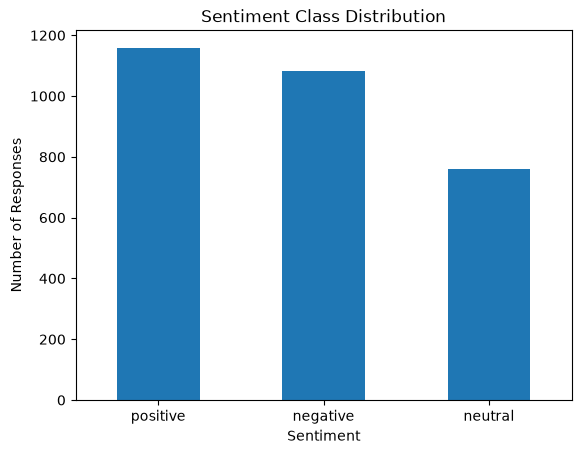

In [3]:
class_counts = df["label"].value_counts()

class_counts.plot(
    kind="bar"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Responses")
plt.title("Sentiment Class Distribution")

plt.xticks(
    rotation=0
)

plt.show()

count    3000.000000
mean        7.295667
std         1.804069
min         3.000000
25%         6.000000
50%         7.000000
75%         8.000000
max        14.000000
Name: document_length, dtype: float64


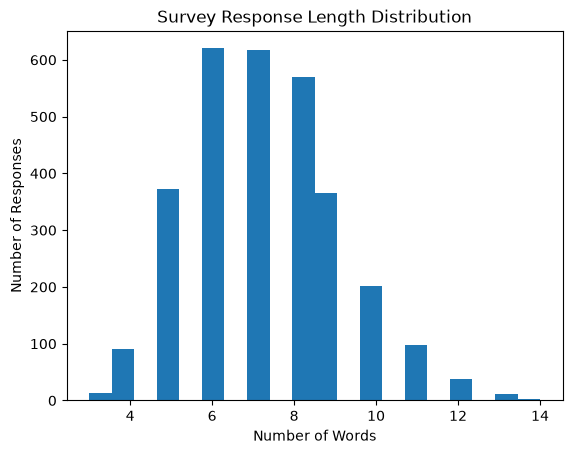

In [4]:
df["document_length"] = df["text"].apply(
    lambda text: len(text.split())
)

print(
    df["document_length"].describe()
)

plt.hist(
    df["document_length"],
    bins=20
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Responses")
plt.title("Survey Response Length Distribution")

plt.show()

In [5]:
for category in categories:

    sample = df[
        df["label"] == category
    ].iloc[0]["text"]

    print(
        f"\n--- {category.upper()} ---"
    )

    print(sample)


--- NEGATIVE ---
for us, account setup has been unreliable

--- NEUTRAL ---
our experience with pricing is average

--- POSITIVE ---
for us, the experience with payroll has been good for our team


In [6]:
stop_words = {
    "the", "is", "a", "an", "and", "or",
    "of", "to", "in", "on", "for",
    "with", "this", "that", "it",
    "as", "are", "was", "were",
    "be", "by", "from", "at",
    "which", "but", "have",
    "has", "had", "they",
    "you", "he", "she",
    "we", "i", "their",
    "our", "your", "my"
}

In [7]:
negators = {
    "not",
    "no",
    "never",
    "cannot",
    "hardly",
    "without"
}


def preprocess_text(text):

    text = text.lower()

    words = re.findall(
        r"\b[a-z]+\b",
        text
    )

    processed_words = []

    negation = False

    for word in words:

        if word in negators:

            negation = True

            processed_words.append(
                word
            )

            continue

        if word in stop_words:

            continue

        if negation:

            processed_words.append(
                "NOT_" + word
            )

            negation = False

        else:

            processed_words.append(
                word
            )

    return processed_words

In [8]:
test_sentences = [
    "The payroll system is excellent",
    "The payroll system is not good",
    "Customer support never replied",
    "The mobile app is very slow"
]

for sentence in test_sentences:

    print(
        "Original:",
        sentence
    )

    print(
        "Processed:",
        preprocess_text(sentence)
    )

    print("-" * 50)

Original: The payroll system is excellent
Processed: ['payroll', 'system', 'excellent']
--------------------------------------------------
Original: The payroll system is not good
Processed: ['payroll', 'system', 'not', 'NOT_good']
--------------------------------------------------
Original: Customer support never replied
Processed: ['customer', 'support', 'never', 'NOT_replied']
--------------------------------------------------
Original: The mobile app is very slow
Processed: ['mobile', 'app', 'very', 'slow']
--------------------------------------------------


In [9]:
# ==========================================
# Preprocess + Split + Build Vocabulary
# ==========================================

# Step 1: Preprocess all text
df["tokens"] = df["text"].apply(
    preprocess_text
)

print("Tokens created successfully.")


# Step 2: Split the dataset
np.random.seed(42)

indices = np.random.permutation(
    len(df)
)

train_end = int(
    0.60 * len(df)
)

val_end = int(
    0.80 * len(df)
)

train_indices = indices[:train_end]

val_indices = indices[
    train_end:val_end
]

test_indices = indices[
    val_end:
]


train_df = df.iloc[
    train_indices
].reset_index(drop=True)

val_df = df.iloc[
    val_indices
].reset_index(drop=True)

test_df = df.iloc[
    test_indices
].reset_index(drop=True)


print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


# Step 3: Build vocabulary ONLY from training data
vocabulary = set()

for tokens in train_df["tokens"]:

    vocabulary.update(
        tokens
    )


# Convert set to ordered list
vocabulary_list = sorted(
    vocabulary
)


# Create word → index mapping
word_to_index = {
    word: index
    for index, word in enumerate(
        vocabulary_list
    )
}


print(
    "Training Vocabulary Size:",
    len(vocabulary_list)
)

print(
    "First 20 words:",
    vocabulary_list[:20]
)

Tokens created successfully.
Train: 1800
Validation: 600
Test: 600
Training Vocabulary Size: 98
First 20 words: ['NOT_figure', 'NOT_strong', 'NOT_work', 'about', 'acceptable', 'account', 'accounting', 'am', 'app', 'average', 'bad', 'been', 'cannot', 'causing', 'confusing', 'currently', 'customer', 'daily', 'described', 'disappointed']


In [10]:
def create_bow(
    tokens,
    word_to_index
):

    vector = np.zeros(
        len(word_to_index),
        dtype=int
    )

    for word in tokens:

        if word in word_to_index:

            vector[
                word_to_index[word]
            ] += 1

    return vector

In [11]:
X_train = np.array([
    create_bow(
        tokens,
        word_to_index
    )
    for tokens in train_df["tokens"]
])

y_train = train_df[
    "label"
].values

print(
    "X_train shape:",
    X_train.shape
)

print(
    "y_train shape:",
    y_train.shape
)

X_train shape: (1800, 98)
y_train shape: (1800,)


In [12]:
class MultinomialNaiveBayes:

    def __init__(
        self,
        alpha=1.0
    ):

        self.alpha = alpha


    def fit(
        self,
        X,
        y
    ):

        self.classes = np.unique(
            y
        )

        self.class_log_prior = {}

        self.feature_log_prob = {}


        for category in self.classes:

            class_mask = (
                y == category
            )

            X_class = X[
                class_mask
            ]


            class_count = (
                X_class.shape[0]
            )


            self.class_log_prior[
                category
            ] = np.log(
                class_count / len(y)
            )


            word_counts = (
                X_class.sum(axis=0)
            )


            total_words = (
                word_counts.sum()
            )


            probabilities = (
                word_counts + self.alpha
            ) / (
                total_words
                +
                self.alpha * X.shape[1]
            )


            self.feature_log_prob[
                category
            ] = np.log(
                probabilities
            )


    def predict(
        self,
        X
    ):

        predictions = []


        for document in X:

            class_scores = {}


            for category in self.classes:

                score = (
                    self.class_log_prior[
                        category
                    ]
                )


                score += np.sum(
                    document
                    *
                    self.feature_log_prob[
                        category
                    ]
                )


                class_scores[
                    category
                ] = score


            prediction = max(
                class_scores,
                key=class_scores.get
            )


            predictions.append(
                prediction
            )


        return np.array(
            predictions
        )


    def predict_proba(
        self,
        X
    ):

        probabilities = []


        for document in X:

            class_scores = []


            for category in self.classes:

                score = (
                    self.class_log_prior[
                        category
                    ]
                )


                score += np.sum(
                    document
                    *
                    self.feature_log_prob[
                        category
                    ]
                )


                class_scores.append(
                    score
                )


            class_scores = np.array(
                class_scores
            )


            # Convert log scores to probabilities
            class_scores -= np.max(
                class_scores
            )


            exp_scores = np.exp(
                class_scores
            )


            probs = (
                exp_scores
                /
                exp_scores.sum()
            )


            probabilities.append(
                probs
            )


        return np.array(
            probabilities
        )

In [13]:
X_val = np.array([
    create_bow(
        tokens,
        word_to_index
    )
    for tokens in val_df["tokens"]
])

y_val = val_df[
    "label"
].values

print(
    "X_val shape:",
    X_val.shape
)

X_val shape: (600, 98)


In [14]:
model = MultinomialNaiveBayes(
    alpha=1.0
)


model.fit(
    X_train,
    y_train
)


y_val_pred = model.predict(
    X_val
)


accuracy = np.mean(
    y_val_pred == y_val
)


print(
    "Validation Accuracy:",
    accuracy
)

Validation Accuracy: 0.9883333333333333


In [15]:
alpha_values = [
    0.1,
    0.5,
    1.0,
    2.0,
    5.0
]

validation_accuracies = []

for alpha in alpha_values:

    model = MultinomialNaiveBayes(
        alpha=alpha
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_val
    )

    accuracy = np.mean(
        predictions == y_val
    )

    validation_accuracies.append(
        accuracy
    )

alpha_results = pd.DataFrame({

    "Alpha": alpha_values,

    "Validation Accuracy":
        validation_accuracies

})

alpha_results

,Alpha,Validation Accuracy
0,0.1,0.988333
1,0.5,0.988333
2,1.0,0.988333
3,2.0,0.988333
4,5.0,0.988333


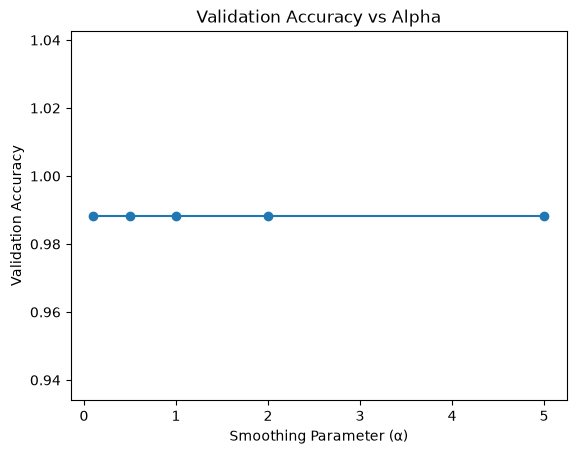

In [16]:
plt.plot(
    alpha_values,
    validation_accuracies,
    marker="o"
)

plt.xlabel(
    "Smoothing Parameter (α)"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Validation Accuracy vs Alpha"
)

plt.show()

In [17]:
best_alpha_index = np.argmax(
    validation_accuracies
)


best_alpha = (
    alpha_values[
        best_alpha_index
    ]
)


print(
    "Best Alpha:",
    best_alpha
)

Best Alpha: 0.1


In [18]:
best_model = MultinomialNaiveBayes(
    alpha=best_alpha
)

best_model.fit(
    X_train,
    y_train
)

print(
    "Best model trained successfully."
)

Best model trained successfully.


In [19]:
top_words = {}

for category in categories:

    probabilities = (
        best_model.feature_log_prob[
            category
        ]
    )

    top_indices = np.argsort(
        probabilities
    )[-15:][::-1]

    words = []

    for index in top_indices:

        word = vocabulary_list[index]

        words.append(
            (
                word,
                probabilities[index]
            )
        )

    top_words[category] = words


for category in categories:

    print(
        f"\n{category.upper()}"
    )

    for word, probability in top_words[category]:

        print(
            word,
            probability
        )


NEGATIVE
experience -3.1063619018918294
tracking -3.217094379551546
use -3.240792170981369
time -3.3241042727263976
too -3.4941642131569552
us -3.6028487045957776
frustrating -3.81998279441369
keeps -3.848928375298768
problems -3.848928375298768
causing -3.848928375298768
expense -3.8637215444765984
reimbursement -3.8637215444765984
support -3.941159599514801
customer -3.941159599514801
been -3.9738957469130725

NEUTRAL
experience -2.9714986015388716
tracking -3.1482551139014343
now -3.2739912817260732
expense -3.748144800974797
reimbursement -3.748144800974797
project -3.788070263383981
average -3.788070263383981
payroll -3.8086471210727404
mobile -3.8730470516758233
app -3.8730470516758233
use -3.8954695157316555
when -3.8954695157316555
time -3.8954695157316555
needed -3.8954695157316555
fine -3.8954695157316555

POSITIVE
experience -3.167849075162681
tracking -3.2838370084008752
work -3.3310527017087734
good -3.380608670716018
time -3.4063390781914977
overall -3.4063390781914977
e

In [20]:
X_test = np.array([
    create_bow(
        tokens,
        word_to_index
    )
    for tokens in test_df["tokens"]
])

y_test = test_df[
    "label"
].values

print(
    "X_test shape:",
    X_test.shape
)

X_test shape: (600, 98)


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_test_pred = best_model.predict(
    X_test
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="weighted"
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="weighted"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)

print(
    "Test Accuracy :", round(test_accuracy, 4)
)

print(
    "Test Precision:", round(test_precision, 4)
)

print(
    "Test Recall   :", round(test_recall, 4)
)

print(
    "Test F1 Score :", round(test_f1, 4)
)

Test Accuracy : 0.99
Test Precision: 0.9903
Test Recall   : 0.99
Test F1 Score : 0.99


In [22]:
confusion_matrix = pd.DataFrame(
    0,
    index=categories,
    columns=categories
)


for actual, predicted in zip(
    y_test,
    y_test_pred
):

    confusion_matrix.loc[
        actual,
        predicted
    ] += 1


confusion_matrix

,negative,neutral,positive
negative,215,6,0
neutral,0,169,0
positive,0,0,210


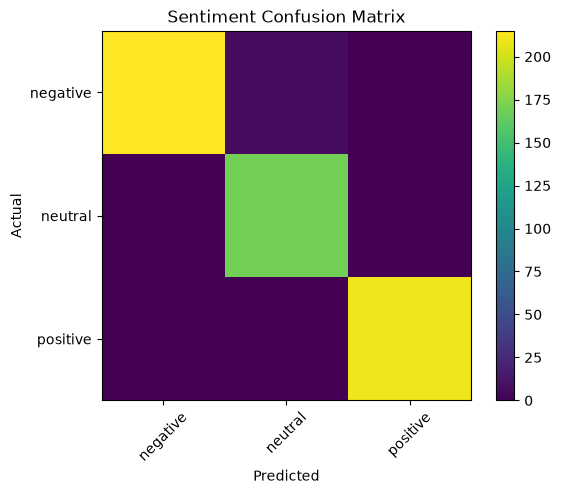

In [23]:
plt.imshow(
    confusion_matrix.values
)

plt.xticks(
    range(len(categories)),
    categories,
    rotation=45
)

plt.yticks(
    range(len(categories)),
    categories
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Sentiment Confusion Matrix"
)

plt.colorbar()

plt.show()

In [24]:
random_baseline = (
    1 / len(categories)
)

print(
    "Random Baseline:",
    random_baseline
)

comparison = pd.DataFrame({

    "Method": [
        "Random Baseline",
        "Naive Bayes"
    ],

    "Accuracy": [
        random_baseline,
        test_accuracy
    ]

})

comparison

Random Baseline: 0.3333333333333333


,Method,Accuracy
0,Random Baseline,0.333333
1,Naive Bayes,0.990000


In [25]:
# ==========================================
# Error Pairs / Wrong Predictions
# ==========================================

wrong_mask = y_test != y_test_pred

wrong_predictions = test_df[wrong_mask].copy()

wrong_predictions["predicted_category"] = (
    y_test_pred[wrong_mask]
)

error_pairs = (
    wrong_predictions[
        ["label", "predicted_category", "text"]
    ]
    .head(10)
)

print("Number of Wrong Predictions:",
      len(wrong_predictions))

print("\nError Pairs:")
display(error_pairs)

Number of Wrong Predictions: 6

Error Pairs:


,label,predicted_category,text
41,negative,neutral,we had a bad experience with payroll
257,negative,neutral,we had a bad experience with payroll
316,negative,neutral,we had a bad experience with mobile app
414,negative,neutral,"currently, we had a bad experience with expens..."
459,negative,neutral,we had a bad experience with project tracking
521,negative,neutral,we had a bad experience with project tracking


In [26]:
# ==========================================
# Least Frequent Words
# ==========================================

word_frequency = Counter()

for tokens in train_df["tokens"]:
    word_frequency.update(tokens)

# Sort all words by frequency
least_frequent_words = sorted(
    word_frequency.items(),
    key=lambda x: x[1]
)

print("Vocabulary Size:", len(word_frequency))

print("\nLeast Frequent Words:")

for word, count in least_frequent_words[:20]:
    print(f"{word}: {count}")

Vocabulary Size: 98

Least Frequent Words:
okay: 27
used: 31
few: 31
times: 31
no: 34
NOT_strong: 34
opinion: 34
about: 34
normal: 34
what: 36
says: 36
acceptable: 38
described: 40
neither: 41
nor: 41
fairly: 41
standard: 41
not: 41
NOT_work: 41
properly: 41


In [27]:
import joblib

model_data = {
    "model": best_model,
    "word_to_index": word_to_index,
    "vocabulary_list": vocabulary_list
}

joblib.dump(
    model_data,
    "sentiment_model.joblib"
)

print(
    "Model saved successfully!"
)

print(
    "File: sentiment_model.joblib"
)

Model saved successfully!
File: sentiment_model.joblib
